In [1]:
import pandas as pd


In [2]:
df=pd.read_csv("BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [4]:
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
cols_to_drop=['CLIENTNUM']
for col in df.columns:
    if "Naive_Bayes" in col:
        cols_to_drop.append(col)

df.drop(columns=cols_to_drop, inplace=True)

df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


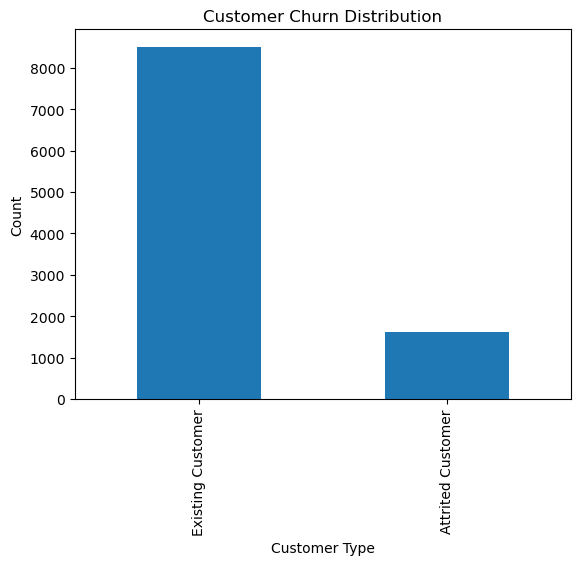

In [7]:
import matplotlib.pyplot as plt

df["Attrition_Flag"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

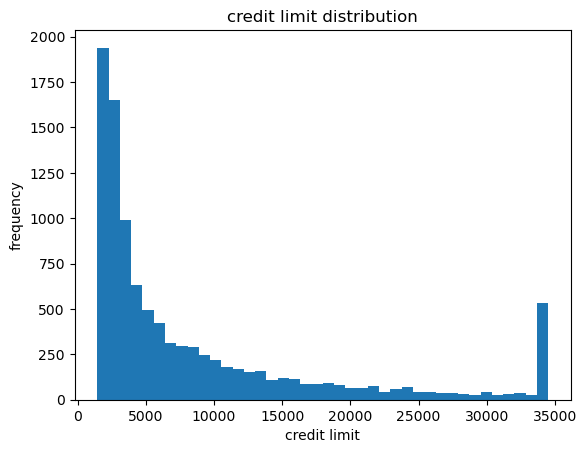

In [8]:
plt.hist(df['Credit_Limit'],bins=40)
plt.title('credit limit distribution')
plt.xlabel('credit limit')
plt.ylabel('frequency')
plt.show()

In [32]:
X=df.drop(columns=['Credit_Limit','Attrition_Flag','Avg_Open_To_Buy','Avg_Utilization_Ratio'])
y=df['Credit_Limit']
X.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,777,1.335,1144,42,1.625
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,864,1.541,1291,33,3.714
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,0,2.594,1887,20,2.333
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,2517,1.405,1171,20,2.333
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,0,2.175,816,28,2.500


In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((8101, 16), (2026, 16))

In [34]:
num_cols=X_train.select_dtypes(include=['int64','float64']).columns
cat_cols=X_train.select_dtypes(include=['object']).columns
print(num_cols)
print(cat_cols)

Index(['Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1'],
      dtype='object')
Index(['Gender', 'Education_Level', 'Marital_Status', 'Income_Category',
       'Card_Category'],
      dtype='object')


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [36]:
preprocessor=ColumnTransformer(
    transformers=[
        ( 
           'numerical',
            StandardScaler(),
            num_cols
        ),
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        )
     ]
    )
    
        

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


In [38]:
linear_model=Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('model',LinearRegression())
    ]
)

In [39]:
linear_model.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
y_pred_linear=linear_model.predict(X_test)
y_pred_linear[:10]

array([ 3818.31945376,  4191.54537769,  3766.08864698,  5753.53290977,
       14382.88760003,  3694.92234124,  8372.33669298, 27330.31044712,
        4247.96596841, 13378.54509211])

In [41]:
from sklearn.metrics import  mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse = np.sqrt(mean_squared_error( y_test,y_pred_linear))
r2 = r2_score( y_test,y_pred_linear)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4120.996780673951
RMSE: 6029.186210167576
R2 Score: 0.5608537322647975


In [42]:
import joblib
joblib.dump(linear_model, 'credit_limit_prediction_LR_model.pkl')

['credit_limit_prediction_LR_model.pkl']

In [77]:
from sklearn.linear_model import Ridge

ridge_model=Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('model',Ridge(alpha=1.0))
    ]
)

In [78]:
ridge_model.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
ridge_pred=ridge_model.predict(X_test)
ridge_pred[:10]

array([ 3819.81324228,  4206.65967566,  3766.22448136,  5767.31758145,
       14380.97293669,  3710.79457237,  8377.12812716, 27276.44129098,
        4259.17788223, 13376.38617774])

In [80]:
ridge_mae = mean_absolute_error( y_test,ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test,ridge_pred ))
ridge_r2 = r2_score(y_test,ridge_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R2:", ridge_r2)

Ridge MAE: 4121.11681693212
Ridge RMSE: 6028.70240661141
Ridge R2: 0.5609242067846759


In [58]:
joblib.dump(ridge_model, 'credit_limit_prediction_Ridge_model.pkl')

['credit_limit_prediction_Ridge_model.pkl']

In [48]:
from sklearn.linear_model import Lasso
lasso_model=Pipeline(
    steps=[
        ('preprocessing',preprocessor),
        ('model',Lasso(alpha=0.1,max_iter=5000))
    ]
)

In [49]:
lasso_model.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
lasso_pred=lasso_model.predict(X_test)
lasso_pred[:10]

array([ 3817.27296293,  4190.73008496,  3764.16049484,  5755.06743373,
       14382.08814568,  3694.42398276,  8372.37773573, 27319.73019749,
        4250.86232202, 13379.27850604])

In [52]:
lasso_mae = mean_absolute_error( y_test,lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test,lasso_pred ))
lasso_r2 = r2_score(y_test,lasso_pred)

print("Lasso MAE:", lasso_mae)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R2:", lasso_r2)

Lasso MAE: 4120.918042787189
Lasso RMSE: 6029.085360407816
Lasso R2: 0.5608684232773679


In [59]:
joblib.dump(lasso_model, 'credit_limit_prediction_lasso_model.pkl')

['credit_limit_prediction_lasso_model.pkl']

In [60]:
regression_results = pd.DataFrame(
    {
        "Model":[
            "Linear Regression",
            "Ridge Regression",
            "Lasso Regression"
        ],
        
        "MAE":[
            mae,
            ridge_mae,
            lasso_mae
        ],
        
        "RMSE":[
            rmse,
            ridge_rmse,
            lasso_rmse
        ],
        
        "R2 Score":[
            r2,
            ridge_r2,
            lasso_r2
        ]
    }
)


regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4120.996781,6029.186210,0.560854
1,Ridge Regression,4121.116817,6028.702407,0.560924
2,Lasso Regression,4120.918043,6029.085360,0.560868


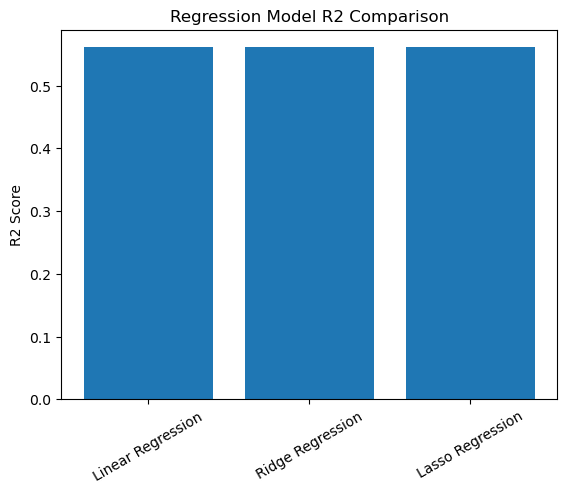

In [81]:
plt.bar( regression_results["Model"],regression_results["R2 Score"])

plt.title("Regression Model R2 Comparison")
plt.ylabel("R2 Score")
plt.xticks( rotation=30)

plt.show()

In [82]:
df["Attrition_Flag"] = df["Attrition_Flag"].map(
    {
        "Existing Customer": 0,
        "Attrited Customer": 1
    }
)
df["Attrition_Flag"].head()

0    0
1    0
2    0
3    0
4    0
Name: Attrition_Flag, dtype: int64

In [83]:
X = df.drop(columns=["Attrition_Flag"])
y = df["Attrition_Flag"]